In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.grad=0.0
        self._backward= lambda: None
        self._prev=set(_children)
        self._op=_op
        self.label=label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        out._backward=_backward
        return out
    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),'*')
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data**(other-1)) * out.grad  # ← not other.data
        out._backward = _backward
        return out
    def __rmul__(self,other):
        return self*other
    def __truediv__(self, other): 
        return self * other**-1
    def __neg__(self):
        return self * -1
    def __sub__(self,other):
        return self +(-other)
    def tanh(self):
        x=self.data
        t= (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t, (self, ),'tanh')
        def _backward():
            self.grad+= (1- t**2) * out.grad
        out._backward=_backward
        return out
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self, ),'exp')
        def _backward():
            self.grad+=out.data *out.grad
        out._backward=_backward
        return out
    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
            node._backward()

In [5]:
from graphviz import Digraph
def trace(root):
    nodes,edges=set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges
def draw_dot(root):
    dot=Digraph(format='svg',graph_attr={'rankdir':'LR'})
    nodes,edges=trace(root)
    for n in nodes:
        uid=str(id(n))
        dot.node(name=uid,label="{ %s |data %.4f| grad %.4f}"%(n.label,n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    return dot

In [231]:
#inputs x1,x2
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
#weights w1,w2
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
#bias of the neuron
b=Value(6.8813735870195432,label='b')
#x1*w1 + x2*w2 +b
x1w1= x1*w1; x1w1.label='x1*w1'
x2w2= x2*w2; x2w2.label='x2*w2'
x1w1x2w2= x1w1 + x2w2; x1w1x2w2.label= 'x1*w1 + x2*w2'
n= x1w1x2w2 + b; n.label='n'
o=n.tanh(); o.label='o'
o.backward()

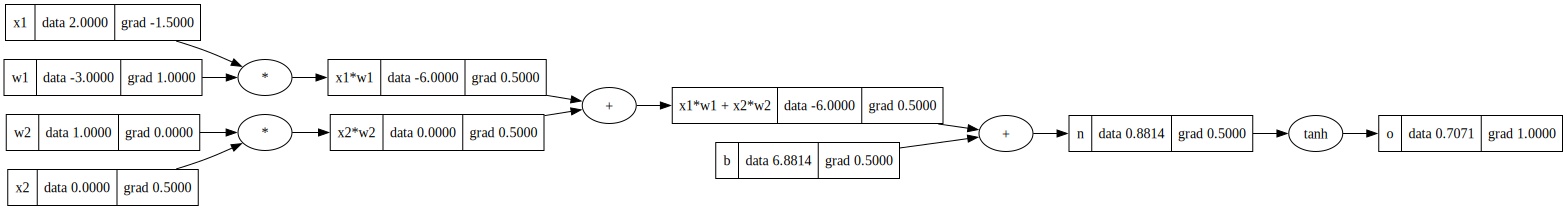

In [225]:
draw_dot(o)

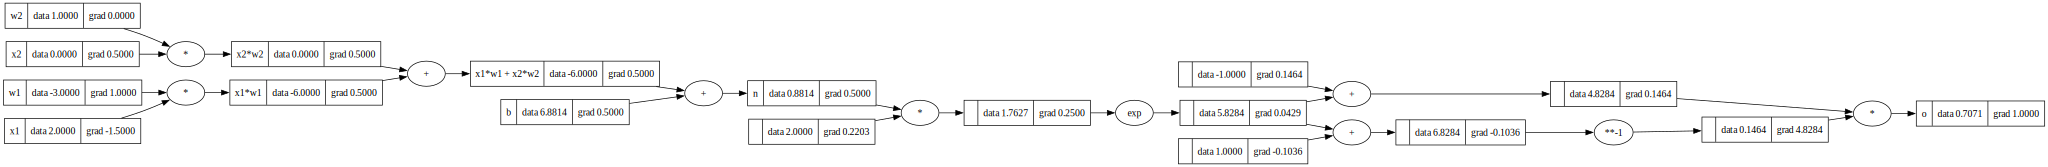

In [239]:
#inputs x1,x2
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
#weights w1,w2
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
#bias of the neuron
b=Value(6.8813735870195432,label='b')
#x1*w1 + x2*w2 +b
x1w1= x1*w1; x1w1.label='x1*w1'
x2w2= x2*w2; x2w2.label='x2*w2'
x1w1x2w2= x1w1 + x2w2; x1w1x2w2.label= 'x1*w1 + x2*w2'
n= x1w1x2w2 + b; n.label='n'
#-------
e=(2*n).exp()
o=(e-1)/(e+1)
#-------- 
o.label='o'
o.backward()
draw_dot(o)

In [6]:
import torch

In [10]:
x1=torch.Tensor([2.0]).double(); x1.requires_grad=True
x2=torch.Tensor([0.0]).double(); x2.requires_grad=True
w1=torch.Tensor([-3.0]).double(); w1.requires_grad=True
w2=torch.Tensor([1.0]).double(); w2.requires_grad=True
b=torch.Tensor([6.8813735870195432]).double(); b.requires_grad=True
n=x1*w1 + x2*w2 + b
o= torch.tanh(n)

print(o.data.item())
o.backward()
print('---')
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('x1',x1.grad.item())
print('w1',w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [11]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [12]:
o.item()

0.7071066904050358

In [37]:
import random
# single forward pass proper

class Neuron:
    def __init__(self, nin):
        self.w=[Value(random.uniform(-1,1)) for _ in range (nin)]
        self.b=Value(random.uniform(-1,1))
    def __call__(self,x):
        act=sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out=act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs=[n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self,nin,nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x

    def parameters(self):
        return [p for layers in self.layers for p in layers.parameters()]



In [38]:
x=[2.0,3.0,-1.0]
n=MLP(3,[4,4,1])
n(x)

Value(data=-0.3395392687579667)

In [41]:
n.parameters()

[Value(data=0.4833482159618405),
 Value(data=-0.7296875305572517),
 Value(data=-0.7276746918969941),
 Value(data=-0.4224999239163083),
 Value(data=-0.6162474652294962),
 Value(data=0.5614028122846868),
 Value(data=0.704005156282945),
 Value(data=0.17596267874850158),
 Value(data=-0.9382771754304462),
 Value(data=0.4987426585253263),
 Value(data=0.4868216679133657),
 Value(data=-0.07029272647402118),
 Value(data=-0.7317901440848116),
 Value(data=0.7374006813789533),
 Value(data=0.9094255958145023),
 Value(data=0.16351671156623815),
 Value(data=-0.4660862177517642),
 Value(data=-0.6513545140794728),
 Value(data=-0.0544688758911307),
 Value(data=-0.6071469481783396),
 Value(data=-0.5943024255522644),
 Value(data=0.813989339827426),
 Value(data=-0.7788588145895632),
 Value(data=-0.12896801945207703),
 Value(data=0.37971100094634425),
 Value(data=-0.9829316419308063),
 Value(data=-0.5786248133873078),
 Value(data=0.3994230357932882),
 Value(data=0.09640249286083002),
 Value(data=0.107419580

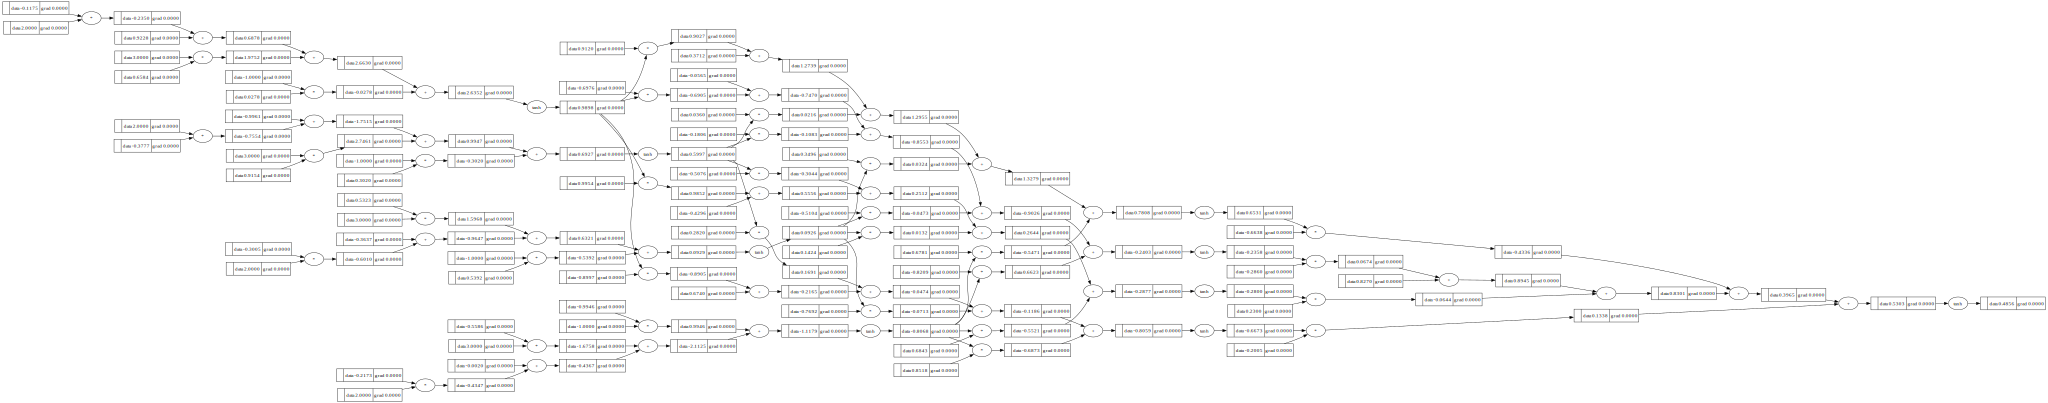

In [21]:
draw_dot(n(x))

In [90]:
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys=[1.0,-1.0,-1.0,1.0]

In [91]:
for k in range(20):
    #forward pass
    ypred=[n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))

    #backward pass
    for p in n.parameters():
        p.grad=0.0
    loss.backward()

    #update(gradient descent)
    for p in n.parameters():
     p.data+=-0.05*p.grad

    print(k,loss.data)

0 7.329268512540737e-11
1 7.3292685104533e-11
2 7.329268508365862e-11
3 7.32926850657814e-11
4 7.329268504304261e-11
5 7.32926850218024e-11
6 7.329268500471782e-11
7 7.329268498124736e-11
8 7.329268496037297e-11
9 7.329268494249574e-11
10 7.329268491975695e-11
11 7.32926849026114e-11
12 7.329268488100536e-11
13 7.329268485832753e-11
14 7.329268484045031e-11
15 7.329268481994177e-11
16 7.329268479647131e-11
17 7.329268477932576e-11
18 7.329268475771971e-11
19 7.329268473690629e-11


In [92]:
ypred

[Value(data=0.9999997254512054),
 Value(data=-0.9999983524073547),
 Value(data=-0.9999916034336199),
 Value(data=0.9999999795257141)]

In [47]:
n.layers[0].neurons[0].w[0].data

0.4833482159618405

In [46]:
n.layers[0].neurons[0].w[0].grad

-0.5438279935663017

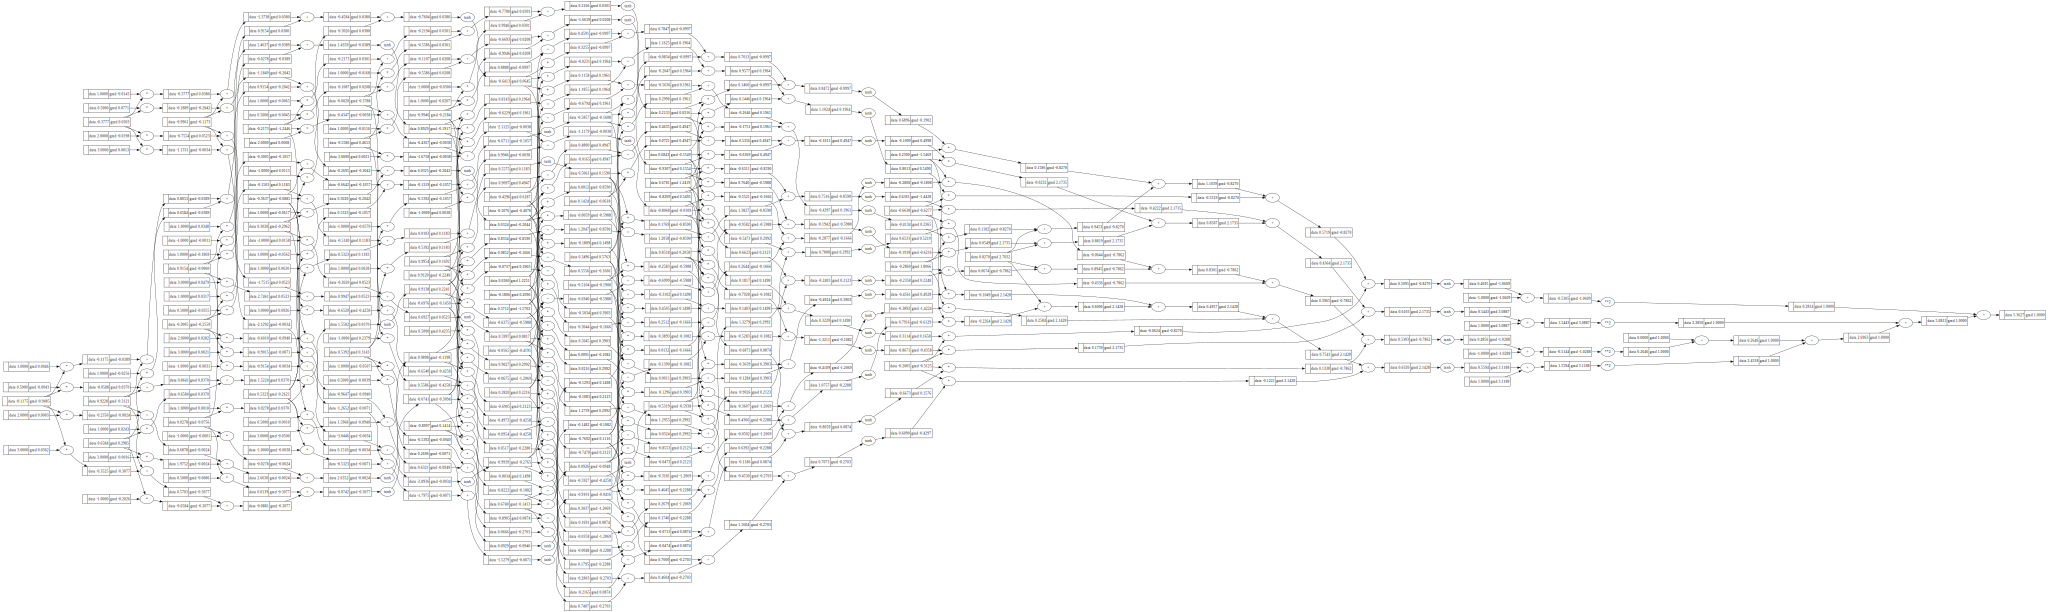

In [36]:
draw_dot(loss)

In [85]:
n.parameters()

[Value(data=0.5632925295069138),
 Value(data=-0.74519841108483),
 Value(data=-0.7053055841676841),
 Value(data=-0.4136903979764728),
 Value(data=-0.3893964395709383),
 Value(data=1.0509660247275916),
 Value(data=0.36497003499150676),
 Value(data=0.3741628933380166),
 Value(data=-1.068413711309706),
 Value(data=0.3636695687461969),
 Value(data=0.7642351661268487),
 Value(data=-0.06917381842217983),
 Value(data=-1.1469437038333834),
 Value(data=0.1146542536086206),
 Value(data=1.2739683244863422),
 Value(data=-0.07847657623843336),
 Value(data=-0.738289620827094),
 Value(data=-0.507718453628282),
 Value(data=-0.07350100684422062),
 Value(data=-0.5614043365217697),
 Value(data=-0.5999854016916283),
 Value(data=1.1286839651247713),
 Value(data=-1.0491261525939324),
 Value(data=-0.3306681384775672),
 Value(data=0.1558104812784068),
 Value(data=-0.8054881545858783),
 Value(data=-0.43001204014523076),
 Value(data=0.29230385159812383),
 Value(data=0.03399621670484565),
 Value(data=0.0238900664